In [32]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [33]:
df = pd.read_csv("CIA_Country_Facts.csv")
df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,NaN,NaN,NaN


#### EDA:

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    object 
 1   Region                              227 non-null    object 
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    float64
 5   Coastline (coast/area ratio)        227 non-null    float64
 6   Net migration                       224 non-null    float64
 7   Infant mortality (per 1000 births)  224 non-null    float64
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    float64
 10  Phones (per 1000)                   223 non-null    float64
 11  Arable (%)                          225 non-n

<Axes: xlabel='Population', ylabel='Count'>

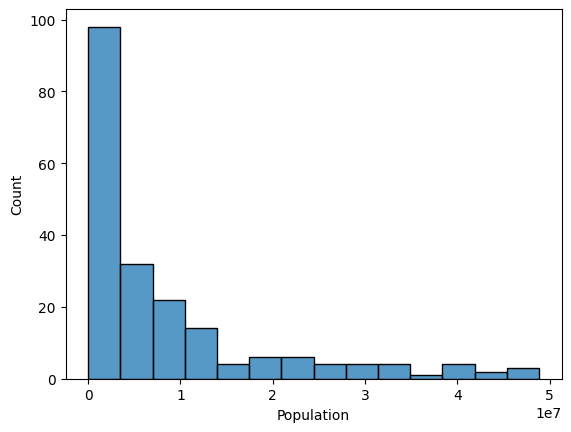

In [35]:
sns.histplot(data = df[df["Population"] < 50000000 ], x = "Population")

<Axes: xlabel='Population', ylabel='Count'>

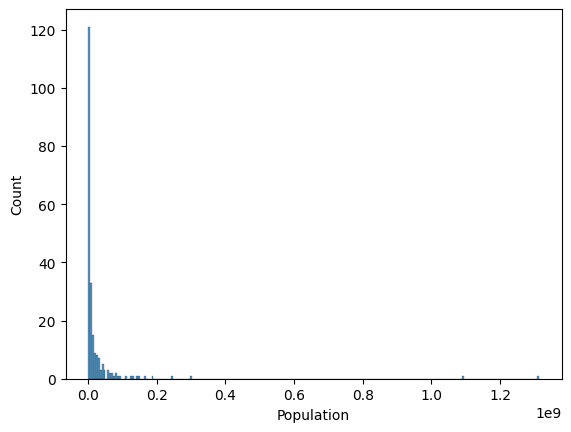

In [36]:
sns.histplot(data = df, x = "Population")

In [37]:
df.columns

Index(['Country', 'Region', 'Population', 'Area (sq. mi.)',
       'Pop. Density (per sq. mi.)', 'Coastline (coast/area ratio)',
       'Net migration', 'Infant mortality (per 1000 births)',
       'GDP ($ per capita)', 'Literacy (%)', 'Phones (per 1000)', 'Arable (%)',
       'Crops (%)', 'Other (%)', 'Climate', 'Birthrate', 'Deathrate',
       'Agriculture', 'Industry', 'Service'],
      dtype='object')

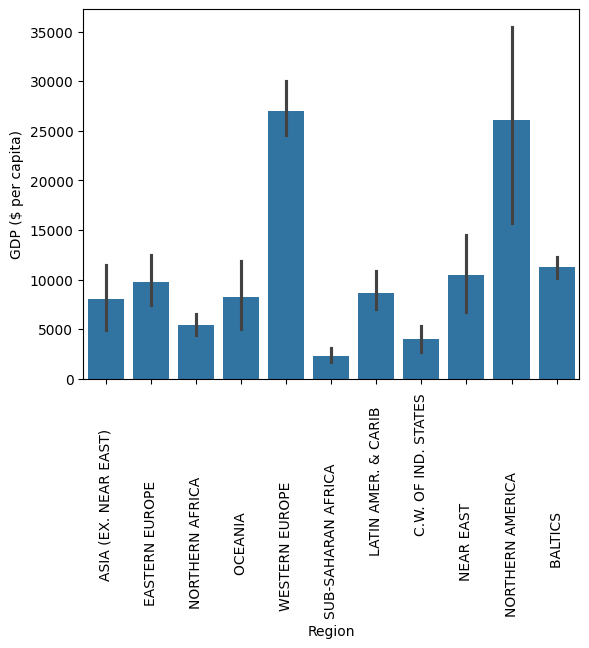

In [38]:
sns.barplot(data= df, y = "GDP ($ per capita)", x = "Region", estimator=np.mean)
plt.xticks(rotation = 90)
plt.show()

<Axes: xlabel='GDP ($ per capita)', ylabel='Literacy (%)'>

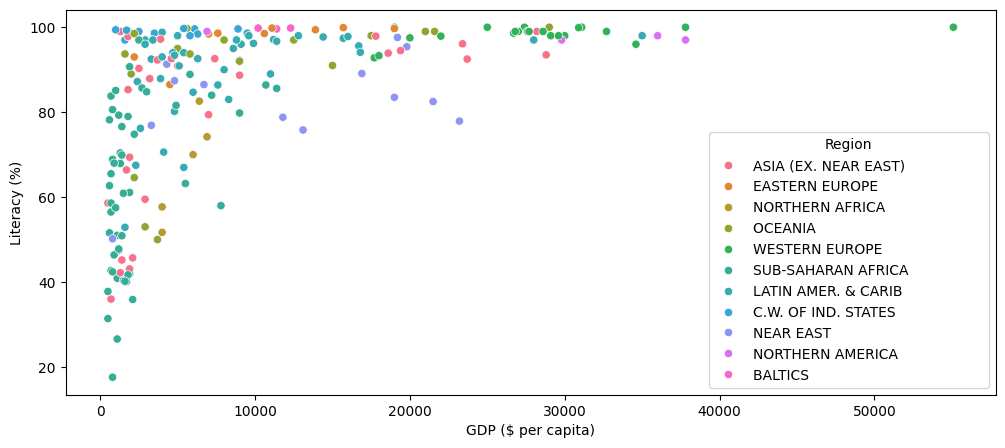

In [39]:
plt.figure(figsize=(12,5))
sns.scatterplot(data= df, x = "GDP ($ per capita)", y = "Literacy (%)", hue = "Region")


####  Missing data 

In [40]:
df.isna().sum()

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          3
Infant mortality (per 1000 births)     3
GDP ($ per capita)                     1
Literacy (%)                          18
Phones (per 1000)                      4
Arable (%)                             2
Crops (%)                              2
Other (%)                              2
Climate                               22
Birthrate                              3
Deathrate                              4
Agriculture                           15
Industry                              16
Service                               15
dtype: int64

In [41]:
df.groupby('Region')["Literacy (%)"].transform('mean')

0      79.553571
1      97.088889
2      67.240000
3      88.835294
4      98.391304
         ...    
222    79.521429
223    67.240000
224    79.521429
225    62.510000
226    62.510000
Name: Literacy (%), Length: 227, dtype: float64

In [42]:
df.tail(2)

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
225,Zambia,SUB-SAHARAN AFRICA,11502010,752614,15.3,0.0,0.0,88.29,800.0,80.6,8.2,7.08,0.03,92.90,2.0,41.00,19.93,0.220,0.290,0.489
226,Zimbabwe,SUB-SAHARAN AFRICA,12236805,390580,31.3,0.0,0.0,67.69,1900.0,90.7,26.8,8.32,0.34,91.34,2.0,28.01,21.84,0.179,0.243,0.579


In [43]:
# Replaced the missing value with the ave literacy rate in that region
df["Literacy (%)"] = df["Literacy (%)"].fillna(df.groupby('Region')["Literacy (%)"].transform('mean'))

In [44]:
df.isna().sum()

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          3
Infant mortality (per 1000 births)     3
GDP ($ per capita)                     1
Literacy (%)                           0
Phones (per 1000)                      4
Arable (%)                             2
Crops (%)                              2
Other (%)                              2
Climate                               22
Birthrate                              3
Deathrate                              4
Agriculture                           15
Industry                              16
Service                               15
dtype: int64

In [45]:
df = df.dropna()

In [46]:
df.isna().sum()

Country                               0
Region                                0
Population                            0
Area (sq. mi.)                        0
Pop. Density (per sq. mi.)            0
Coastline (coast/area ratio)          0
Net migration                         0
Infant mortality (per 1000 births)    0
GDP ($ per capita)                    0
Literacy (%)                          0
Phones (per 1000)                     0
Arable (%)                            0
Crops (%)                             0
Other (%)                             0
Climate                               0
Birthrate                             0
Deathrate                             0
Agriculture                           0
Industry                              0
Service                               0
dtype: int64

In [47]:
df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
6,Anguilla,LATIN AMER. & CARIB,13477,102,132.1,59.80,10.76,21.03,8600.0,95.0,460.0,0.00,0.00,100.00,2.0,14.17,5.34,0.040,0.180,0.780
7,Antigua & Barbuda,LATIN AMER. & CARIB,69108,443,156.0,34.54,-6.15,19.46,11000.0,89.0,549.9,18.18,4.55,77.27,2.0,16.93,5.37,0.038,0.220,0.743


In [48]:
X = df.drop("Country", axis = 1)
X = pd.get_dummies(X)
X.head()

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),...,Region_BALTICS,Region_C.W. OF IND. STATES,Region_EASTERN EUROPE,Region_LATIN AMER. & CARIB,Region_NEAR EAST,Region_NORTHERN AFRICA,Region_NORTHERN AMERICA,Region_OCEANIA,Region_SUB-SAHARAN AFRICA,Region_WESTERN EUROPE
0,31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,...,False,False,False,False,False,False,False,False,False,False
1,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,...,False,False,True,False,False,False,False,False,False,False
2,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,...,False,False,False,False,False,True,False,False,False,False
6,13477,102,132.1,59.80,10.76,21.03,8600.0,95.0,460.0,0.00,...,False,False,False,True,False,False,False,False,False,False
7,69108,443,156.0,34.54,-6.15,19.46,11000.0,89.0,549.9,18.18,...,False,False,False,True,False,False,False,False,False,False


In [49]:
#Scale this data 
from sklearn.preprocessing import StandardScaler

In [50]:
sc = StandardScaler()
sc_X = sc.fit_transform(X) # Scaled X 

In [51]:
# sc_X

In [52]:
from sklearn.cluster import KMeans

In [53]:
# To get the optimum num of clusters. 
ssd = []
for k in range(2, 16):
    model = KMeans(n_clusters=k)
    model.fit(sc_X)

    ssd.append(model.inertia_)

Text(0, 0.5, 'Sum of Squares of Distance')

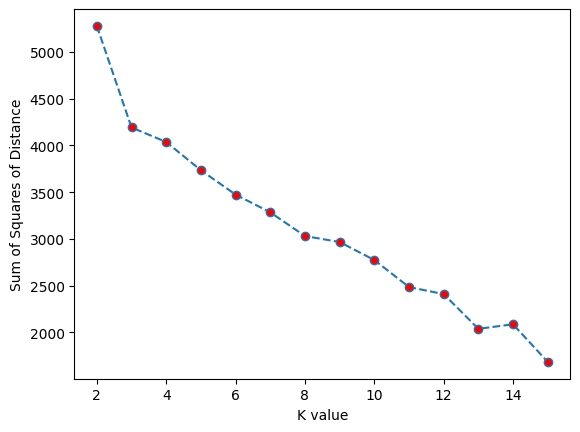

In [55]:
plt.plot(range(2,16), ssd, 'o--', mfc = 'red')
plt.xlabel("K value")
plt.ylabel("Sum of Squares of Distance")

<Axes: >

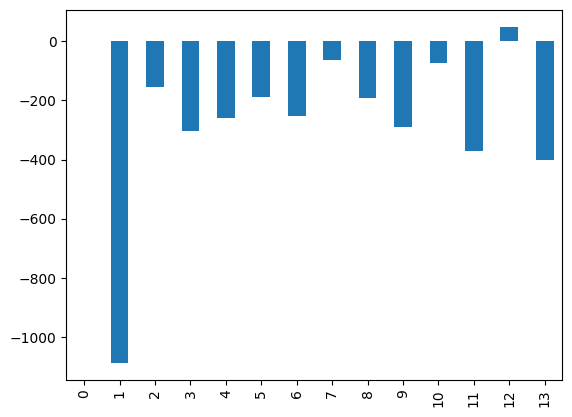

In [56]:
pd.Series(ssd).diff().plot(kind = 'bar')

### Now Train the model with three cluster. 

In [57]:
model = KMeans(n_clusters=3)
model.fit(sc_X)


KMeans(n_clusters=3)

In [59]:
X['K=3'] = model.labels_

In [62]:
X.corr()['K=3']

Population                                   -0.075667
Area (sq. mi.)                                0.063733
Pop. Density (per sq. mi.)                    0.228551
Coastline (coast/area ratio)                  0.313560
Net migration                                 0.036736
Infant mortality (per 1000 births)            0.412958
GDP ($ per capita)                           -0.195250
Literacy (%)                                 -0.326141
Phones (per 1000)                            -0.305987
Arable (%)                                   -0.186725
Crops (%)                                     0.212342
Other (%)                                     0.035895
Climate                                      -0.269512
Birthrate                                     0.440123
Deathrate                                     0.264470
Agriculture                                   0.375422
Industry                                     -0.228308
Service                                      -0.145799
Region_ASI

In [70]:
labels = model.predict(sc_X)
df["cluster"] = labels
df.groupby("cluster").mean(numeric_only=True)

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
cluster,,,,,,,,,,,,,,,,,,
0,4.062079e+07,496022.690265,189.500885,8.624956,-0.347965,17.997522,11961.946903,91.445546,300.260177,15.674425,4.013363,80.311239,2.345133,16.659115,7.249912,0.084991,0.304991,0.609159
1,2.128338e+07,480926.298246,86.503509,0.986842,0.101579,83.137544,1938.596491,61.264912,18.752632,12.380702,3.379123,84.240526,1.780702,36.394561,14.577368,0.300386,0.273456,0.426298
2,1.689269e+07,884440.300000,1633.620000,114.149500,-0.026000,19.017500,13270.000000,92.340294,280.070000,8.259000,12.591000,79.150000,2.050000,19.591000,6.225500,0.126000,0.197700,0.675750


This is unsupervised learning, so there are no labels.
We train the model using the data to find cluster centroids.
After training, the model groups the data into three clusters.
We then interpret the meaning of each cluster based on the features of the data points in that cluster.
When new data arrives, we use the same trained model to predict which cluster it belongs to.
Based on the previous interpretation of that cluster, we can infer the likely characteristics of the new data.

In [72]:
# Find which cluster has the highest value for each feature 
cluster_mean = df.groupby("cluster").mean(numeric_only=True)
cluster_mean.idxmax()

Population                            0
Area (sq. mi.)                        2
Pop. Density (per sq. mi.)            2
Coastline (coast/area ratio)          2
Net migration                         1
Infant mortality (per 1000 births)    1
GDP ($ per capita)                    2
Literacy (%)                          2
Phones (per 1000)                     0
Arable (%)                            0
Crops (%)                             2
Other (%)                             1
Climate                               0
Birthrate                             1
Deathrate                             1
Agriculture                           1
Industry                              0
Service                               2
dtype: int32

In [73]:
cluster_mean.idxmin()

Population                            2
Area (sq. mi.)                        1
Pop. Density (per sq. mi.)            1
Coastline (coast/area ratio)          1
Net migration                         0
Infant mortality (per 1000 births)    0
GDP ($ per capita)                    1
Literacy (%)                          1
Phones (per 1000)                     1
Arable (%)                            2
Crops (%)                             1
Other (%)                             2
Climate                               1
Birthrate                             0
Deathrate                             2
Agriculture                           0
Industry                              2
Service                               1
dtype: int32

In [74]:
cluster_mean

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
cluster,,,,,,,,,,,,,,,,,,
0,4.062079e+07,496022.690265,189.500885,8.624956,-0.347965,17.997522,11961.946903,91.445546,300.260177,15.674425,4.013363,80.311239,2.345133,16.659115,7.249912,0.084991,0.304991,0.609159
1,2.128338e+07,480926.298246,86.503509,0.986842,0.101579,83.137544,1938.596491,61.264912,18.752632,12.380702,3.379123,84.240526,1.780702,36.394561,14.577368,0.300386,0.273456,0.426298
2,1.689269e+07,884440.300000,1633.620000,114.149500,-0.026000,19.017500,13270.000000,92.340294,280.070000,8.259000,12.591000,79.150000,2.050000,19.591000,6.225500,0.126000,0.197700,0.675750
